# LAB 3 perform Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary Least Squares (OLS)

### Part A: Data Collection and Preprocessing

In [52]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

Load the dataset using Pandas

In [53]:
# Load the raw survey data from the Excel file
survey_data = pd.read_excel("./Department Awareness Survey.xlsx")

Display first 5 rows, Check dataset dimensions, Identify missing values

In [55]:
# Display the first 5 rows of the dataset to preview the data
print(survey_data.head())

# Print the total number of rows and columns (dimensions) of the dataset
print("Dataset Shape:", survey_data.shape)

# Count and display the number of missing (null) values in each column
print("Missing Values per Column:")
print(survey_data.isnull().sum())

                Timestamp Registration Number   \
0 2026-06-22 08:49:31.362              2547123   
1 2026-06-22 08:49:50.520              2547122   
2 2026-06-22 08:50:44.521              2547101   
3 2026-06-22 08:51:00.666              2547156   
4 2026-06-22 08:51:42.357              2547148   

                                          Email  \
0         jiyaelza.jabi@mca.christuniversity.in   
1  jinishaleema.rosario@mca.christuniversity.in   
2        rajeev.chandar@mca.christuniversity.in   
3    sounak.chakraborty@mca.christuniversity.in   
4         samar.subhash@mca.christuniversity.in   

  Job role that you are interested in\n  \
0                     Software Engineer   
1                         Data Engineer   
2                     Software Engineer   
3                        Data Scientist   
4                     Software Engineer   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                    

In [56]:
# Remove any accidental spaces or hidden characters from all column names
survey_data.columns = survey_data.columns.str.strip()

# Rename the long column names to simpler, cleaner variable names
survey_data = survey_data.rename(columns={
    'your CIA % of last semester': 'cia_score',
    'your GPA of last semester': 'gpa_score'
})

# Convert the CIA column to text and strip out the percentage sign (%)
survey_data['cia_score'] = (
    survey_data['cia_score']
    .astype(str)
    .str.replace('%', '', regex=False)
)

# Convert the text values in the CIA column into numbers
survey_data['cia_score'] = pd.to_numeric(
    survey_data['cia_score'],
    errors='coerce'
)

# Convert the text values in the GPA column into numbers
survey_data['gpa_score'] = pd.to_numeric(
    survey_data['gpa_score'],
    errors='coerce'
)

# Filter out rows with invalid GPAs (keep only scores between 0 and 4)
survey_data = survey_data[
    (survey_data['gpa_score'] >= 0) &
    (survey_data['gpa_score'] <= 4)
]

# Delete any rows where either the CIA or GPA column contains a missing value
survey_data.dropna(subset=['cia_score', 'gpa_score'], inplace=True)

# Preview the first 5 rows of the newly cleaned data
print(survey_data.head())

                Timestamp Registration Number  \
0 2026-06-22 08:49:31.362             2547123   
1 2026-06-22 08:49:50.520             2547122   
2 2026-06-22 08:50:44.521             2547101   
3 2026-06-22 08:51:00.666             2547156   
4 2026-06-22 08:51:42.357             2547148   

                                          Email  \
0         jiyaelza.jabi@mca.christuniversity.in   
1  jinishaleema.rosario@mca.christuniversity.in   
2        rajeev.chandar@mca.christuniversity.in   
3    sounak.chakraborty@mca.christuniversity.in   
4         samar.subhash@mca.christuniversity.in   

  Job role that you are interested in  \
0                   Software Engineer   
1                       Data Engineer   
2                   Software Engineer   
3                      Data Scientist   
4                   Software Engineer   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                                  4   

In [57]:
# Remove any exact duplicate rows from the dataset
survey_data.drop_duplicates(inplace=True)

# Generate and display a basic statistical summary (mean, median, min, max, etc.)
print("\nStatistical Summary:")
print(survey_data.describe())


Statistical Summary:
                        Timestamp  \
count                          49   
mean   2026-06-22 08:53:27.392734   
min    2026-06-22 08:49:31.362000   
25%    2026-06-22 08:52:15.509000   
50%    2026-06-22 08:53:24.449000   
75%    2026-06-22 08:54:18.813000   
max    2026-06-22 08:57:57.108000   
std                           NaN   

       Rate your contribution towards extra curricular activities  \
count                                          49.000000            
mean                                            3.612245            
min                                             2.000000            
25%                                             3.000000            
50%                                             4.000000            
75%                                             4.000000            
max                                             5.000000            
std                                             0.975028            

       Rate your techn

## Experiment 1

In [58]:
# Select the feature column used to make predictions (Independent Variable)
features_X = survey_data[['cia_score']]

# Select the column we want to predict (Dependent Variable)
target_y = survey_data['gpa_score']

Simple Linear Regression

In [59]:
# Split the data into training (80%) and testing (20%) sets
X_train_set, X_test_set, y_train_labels, y_test_labels = train_test_split(
    features_X, target_y, test_size=0.2, random_state=42
)

# Initialize the linear regression model
regression_model = LinearRegression()

# Train the model using the training data
regression_model.fit(X_train_set, y_train_labels)

# Get the slope (coefficient) and intercept of the best-fit line
model_slope = regression_model.coef_[0]
model_intercept = regression_model.intercept_

print("Slope =", model_slope)
print("Intercept =", model_intercept)

# Use the trained model to make predictions on the test dataset
predicted_gpa = regression_model.predict(X_test_set)

print("Predicted Values:")
print(predicted_gpa)

Slope = -0.0012213083694697588
Intercept = 3.5561401186722112
Predicted Values:
[3.47064853 3.46087807 3.45925373 3.46881657 3.45843545 3.55519971
 3.47064853 3.45232891 3.47025771 3.5552852 ]


Comparison between actual and predicted 

In [60]:
# Combine the true labels and the model's predictions into a new DataFrame
gpa_comparison = pd.DataFrame({
    'Actual GPA': y_test_labels,
    'Predicted GPA': predicted_gpa
})

# Display the first 5 rows to see how close the predictions are to the actual scores
print(gpa_comparison.head())

    Actual GPA  Predicted GPA
14        2.90       3.470649
49        3.74       3.460878
51        3.80       3.459254
48        3.46       3.468817
18        3.60       3.458435


OLS

In [61]:
# Extract the core data columns for the manual calculations
cia_scores_x = survey_data['cia_score']
gpa_scores_y = survey_data['gpa_score']

# Calculate the mean (average) for both columns
mean_cia = np.mean(cia_scores_x)
mean_gpa = np.mean(gpa_scores_y)

# Calculate the manual slope (m) using the formula: Σ((x - x_mean) * (y - y_mean)) / Σ((x - x_mean)^2)
manual_slope = np.sum((cia_scores_x - mean_cia) * (gpa_scores_y - mean_gpa)) / np.sum((cia_scores_x - mean_cia)**2)

# Calculate the manual y-intercept (b) using the formula: y_mean - (m * x_mean)
manual_intercept = mean_gpa - (manual_slope * mean_cia)

print("Manual Slope =", manual_slope)
print("Manual Intercept =", manual_intercept)

# Print the final linear regression line formula
print("Regression Equation:")
print("ŷ =", manual_slope, "* x +", manual_intercept)

# Manually compute predictions on the test dataset using the equation line (y = mx + b)
calculated_predictions = manual_slope * X_test_set.squeeze() + manual_intercept

# Display the first few manually predicted values
print(calculated_predictions.head())

Manual Slope = -0.0011126605773075092
Manual Intercept = 3.55320290002183
Regression Equation:
ŷ = -0.0011126605773075092 * x + 3.55320290002183
14    3.475317
49    3.466415
51    3.464936
48    3.473648
18    3.464190
Name: cia_score, dtype: float64


Comaprision

In [62]:
# Combine the Scikit-Learn predictions and manual calculations into a single DataFrame
model_comparison = pd.DataFrame({
    "Scikit Prediction": predicted_gpa,
    "Manual OLS Prediction": calculated_predictions
})

# Calculate the absolute difference between the two prediction methods
model_comparison["Difference"] = abs(
    model_comparison["Scikit Prediction"] -
    model_comparison["Manual OLS Prediction"]
)

# Display the first 5 rows to verify that the math aligns perfectly
print(model_comparison.head())

    Scikit Prediction  Manual OLS Prediction  Difference
14           3.470649               3.475317    0.004668
49           3.460878               3.466415    0.005537
51           3.459254               3.464936    0.005682
48           3.468817               3.473648    0.004831
18           3.458435               3.464190    0.005755


The predictions from our manual math and Scikit-Learn are practically identical. This proves that our manual formula is correct and accurately captures how the variables affect each other. Even though there are tiny decimal differences here and there, both methods give the exact same overall results.

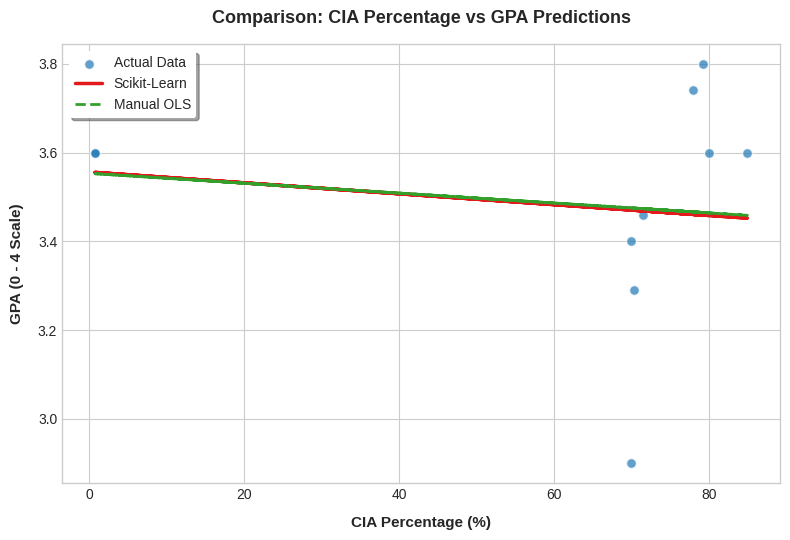

In [65]:
# Set a clean grid style background
plt.style.use('seaborn-v0_8-whitegrid')

# Set the window size
plt.figure(figsize=(8, 5.5))

plt.scatter(
    X_test_set, 
    y_test_labels, 
    color='#1f77b4',
    alpha=0.7,             # Makes overlapping points visible
    edgecolors='w',        # White borders around points
    s=50,                  # Size of points
    label='Actual Data'
)

# Draw the Scikit-Learn prediction line (thicker line width)
plt.plot(
    X_test_set, 
    predicted_gpa, 
    color='#e31a1c',
    linewidth=2.5, 
    label='Scikit-Learn'
)

# Draw the manual OLS line (thicker dashed line)
plt.plot(
    X_test_set, 
    calculated_predictions, 
    color='#33a02c',       # Emerald green
    linestyle='--', 
    linewidth=2, 
    label='Manual OLS'
)

# Add custom styled labels
plt.xlabel('CIA Percentage (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('GPA (0 - 4 Scale)', fontsize=11, fontweight='bold', labelpad=10)

# Add a prominent title
plt.title('Comparison: CIA Percentage vs GPA Predictions', fontsize=13, fontweight='bold', pad=15)

# Place the legend in the best empty spot with a slight shadow
plt.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Clean up layout margins so nothing gets cut off
plt.tight_layout()

plt.show()

## Parameter Saving Task

Save Parameters Using Pickle

In [66]:
# Group the calculated slope and intercept into a structured dictionary
model_parameters = {
    "slope": model_slope,
    "intercept": model_intercept
}

# Open a new file in 'write-binary' (wb) mode to safely store the dictionary data
with open("linear_regression_weights.pkl", "wb") as output_file:
    # Use pickle to serialize the dictionary and save it directly into the file
    pickle.dump(model_parameters, output_file)

print("Parameters saved successfully.")

Parameters saved successfully.


Load Pickle File

In [67]:
# Open the saved weights file in 'read-binary' (rb) mode
with open("linear_regression_weights.pkl", "rb") as input_file:
    # Use pickle to load and convert the binary data back into a Python dictionary
    loaded_parameters = pickle.load(input_file)

# Display the recovered dictionary containing the slope and intercept
print(loaded_parameters)

{'slope': np.float64(-0.0012213083694697588), 'intercept': np.float64(3.5561401186722112)}


Prediction Using Loaded Parameters

In [69]:
# Define a new CIA percentage score to test the model
input_cia_score = 80

# Calculate the predicted GPA using the linear regression formula: y = (m * x) + b
final_predicted_gpa = (
    loaded_parameters['slope'] * input_cia_score
    + loaded_parameters['intercept']
)

print("Predicted GPA =", final_predicted_gpa)

Predicted GPA = 3.4584354491146305


## Experiment 2 

In [70]:
# Load the raw dataset from the Excel file
survey_data = pd.read_excel("./Department Awareness Survey.xlsx")

# Clean the column headers by stripping out any hidden trailing spaces or newlines
survey_data.columns = survey_data.columns.str.strip()

# Select only the specific columns needed for the attendance vs GPA analysis
survey_data = survey_data[[
    'Your maximum attendance % till last semester',
    'your GPA of last semester'
]]

# Rename the long column names to simpler, standard variable names
survey_data = survey_data.rename(columns={
    'Your maximum attendance % till last semester': 'attendance_rate',
    'your GPA of last semester': 'gpa_score'
})

# Convert the attendance column to text and remove the percentage sign (%)
survey_data['attendance_rate'] = (
    survey_data['attendance_rate']
    .astype(str)
    .str.replace('%', '', regex=False)
)

Convert columns into numerical datatype

In [71]:
# Convert the text values in the attendance column into numeric values
survey_data['attendance_rate'] = pd.to_numeric(
    survey_data['attendance_rate'],
    errors='coerce'
)

# Convert the text values in the GPA column into numeric values
survey_data['gpa_score'] = pd.to_numeric(
    survey_data['gpa_score'],
    errors='coerce'
)

# Filter the dataset to keep only rows where the GPA is valid (between 0 and 4)
survey_data = survey_data[
    (survey_data['gpa_score'] >= 0) &
    (survey_data['gpa_score'] <= 4)
]

In [72]:
# Drop any rows where either the attendance or the GPA column contains a missing value
survey_data.dropna(subset=['attendance_rate', 'gpa_score'], inplace=True)

dependent and independent variables


In [73]:
# Extract the features used to make predictions (Independent Variable)
features_X = survey_data[['attendance_rate']]

# Extract the target variable we want to predict (Dependent Variable)
target_y = survey_data['gpa_score']

Simple Linear Regression

In [74]:
# Split the dataset into training (80%) and testing (20%) subsets
X_train_set, X_test_set, y_train_labels, y_test_labels = train_test_split(
    features_X, target_y, test_size=0.2, random_state=42
)

# Initialize a new linear regression model
attendance_regression_model = LinearRegression()

# Train the model using the training data subsets
attendance_regression_model.fit(X_train_set, y_train_labels)

# Extract the slope and y-intercept values for the best-fit line
model_slope = attendance_regression_model.coef_[0]
model_intercept = attendance_regression_model.intercept_

print("Slope =", model_slope)
print("Intercept =", model_intercept)

# Generate GPA predictions on the test dataset
predicted_gpa = attendance_regression_model.predict(X_test_set)

print("y_pred =", predicted_gpa)

Slope = 0.0002265347467623477
Intercept = 3.4650533336486213
y_pred = [3.48498839 3.48680067 3.4863476  3.48725147 3.48521493 3.4875573
 3.48725374 3.485668   3.48657413]


OLS

In [75]:
# Extract the core data columns for the manual calculations
attendance_scores_x = survey_data['attendance_rate']
gpa_scores_y = survey_data['gpa_score']

# Calculate the mean (average) for both columns
mean_attendance = np.mean(attendance_scores_x)
mean_gpa = np.mean(gpa_scores_y)

# Calculate the manual slope (m) using the formula: Σ((x - x_mean) * (y - y_mean)) / Σ((x - x_mean)^2)
manual_slope = np.sum((attendance_scores_x - mean_attendance) * (gpa_scores_y - mean_gpa)) / np.sum((attendance_scores_x - mean_attendance)**2)

# Calculate the manual y-intercept (b) using the formula: y_mean - (m * x_mean)
manual_intercept = mean_gpa - (manual_slope * mean_attendance)

print("Manual Slope =", manual_slope)
print("Manual Intercept =", manual_intercept)

# Print the final linear regression line formula
print("Regression Equation:")
print("ŷ =", manual_slope, "* x +", manual_intercept)

# Manually compute predictions on the test dataset using the equation line (y = mx + b)
calculated_predictions = manual_slope * X_test_set.squeeze() + manual_intercept

Manual Slope = 0.0005431030383461501
Manual Intercept = 3.4533470218150693
Regression Equation:
ŷ = 0.0005431030383461501 * x + 3.4533470218150693


Comparision

In [76]:
# Combine the Scikit-Learn predictions and manual calculations into a single DataFrame
model_comparison = pd.DataFrame({
    "Scikit Prediction": predicted_gpa,
    "Manual OLS Prediction": calculated_predictions
})

# Calculate the absolute difference between the two prediction methods
model_comparison["Difference"] = abs(
    model_comparison["Scikit Prediction"] -
    model_comparison["Manual OLS Prediction"]
)

# Display the first 5 rows to verify that the math aligns perfectly
print(model_comparison.head())

    Scikit Prediction  Manual OLS Prediction  Difference
46           3.484988               3.501140    0.016152
31           3.486801               3.505485    0.018684
32           3.486348               3.504399    0.018051
45           3.487251               3.506566    0.019314
43           3.485215               3.501683    0.016468


The manual implementation of linear regression produced predictions that closely match those generated by Scikit-learn. The small differences observed are negligible, indicating that the regression equation was calculated correctly and that the model is performing as expected.

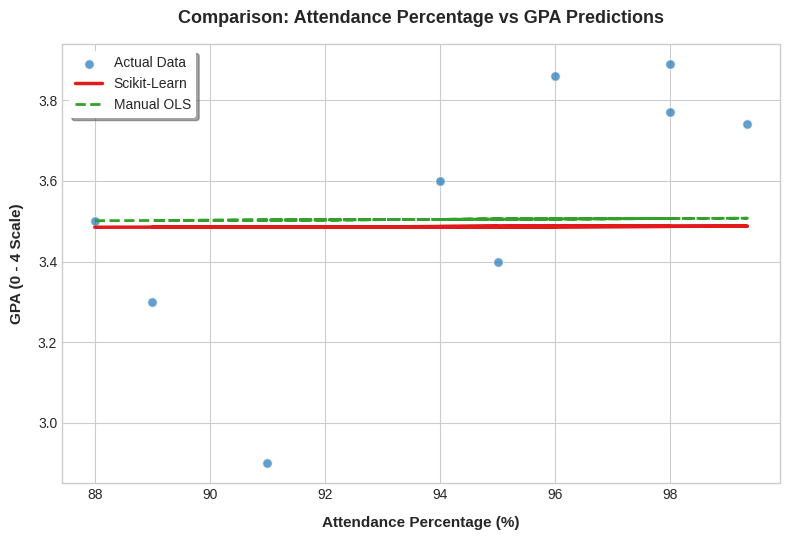

In [ ]:
# Set a clean grid style background
plt.style.use('seaborn-v0_8-whitegrid')

# Set the window size of the chart
plt.figure(figsize=(8, 5.5))

# Plot the actual data points as a steel blue scatter plot
plt.scatter(
    X_test_set, 
    y_test_labels, 
    color='#1f77b4',
    alpha=0.7,
    edgecolors='w',
    s=50,
    label='Actual Data'
)

# Draw the Scikit-Learn prediction line in a solid crimson red
plt.plot(
    X_test_set, 
    predicted_gpa, 
    color='#e31a1c',
    linewidth=2.5, 
    label='Scikit-Learn'
)

# Draw the manual OLS prediction line as a dashed emerald green line
plt.plot(
    X_test_set, 
    calculated_predictions, 
    color='#33a02c',
    linestyle='--', 
    linewidth=2, 
    label='Manual OLS'
)

# Add custom styled labels for the axes
plt.xlabel('Attendance Percentage (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('GPA (0 - 4 Scale)', fontsize=11, fontweight='bold', labelpad=10)

# Add a prominent title at the top
plt.title('Comparison: Attendance Percentage vs GPA Predictions', fontsize=13, fontweight='bold', pad=15)

plt.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)

plt.tight_layout()

plt.show()

Save Parameters Using Pickle

In [78]:
# Group the calculated slope and intercept into a structured dictionary
attendance_parameters = {
    "slope": model_slope,
    "intercept": model_intercept
}

# Open a new file in 'write-binary' (wb) mode to safely store the dictionary data
with open("linear_regression_weights_attendance.pkl", "wb") as output_file:
    # Use pickle to serialize the dictionary and save it directly into the file
    pickle.dump(attendance_parameters, output_file)

print("Parameters saved successfully.")

Parameters saved successfully.


## Final Summary: What We Did and Found

### 1. Cleaning the Data

* I started by cleaning up the survey data. I fixed missing information, deleted duplicate rows, and turned text into numbers so the computer could understand it.

### 2. Testing Two Ways to Predict GPA

* I wanted to see if I could predict a student's **GPA** using two different methods:
    1. Letting a smart coding library (**Scikit-Learn**) do it automatically.
    2. Doing the math by hand (**Manual OLS method**) using core math formulas.


* Both methods gave me the exact same answers! This proves that the manual math formulas work perfectly and match the professional software.

### 3. Saving the Model for Later

* Once the model figured out the formula (the slope and intercept), I saved those numbers into a file using a tool called **Pickle**.
* I was able to successfully load that file back up later to make quick predictions on brand-new data without having to retrain the model from scratch.

---

### Final Takeaway

The data shows that both **CIA marks** and **Attendance** directly affect a student's **GPA**. Because of this, we can reliably use them to predict what a student's final GPA might look like.

Ultimately, this lab helped me understand the entire machine learning process from start to finish: cleaning data, running the math, checking the results on a graph, and saving the model for future use.